# Phase 3: Marine Heatwave Detection

This notebook detects marine heatwave events along the California coast using NOAA OISST daily SST data.

Definition used in this project:

- Baseline period: 1982–2011
- Threshold: seasonally varying daily 90th percentile SST
- Event rule: SST exceeds threshold for at least 5 consecutive days

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

from src.marine_heatwaves import (
    calculate_climatology,
    add_anomalies_and_thresholds,
    detect_marine_heatwaves,
    summarize_events_by_year,
)


In [2]:
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

SST_PATH = PROCESSED_DIR / "california_daily_sst_1982_2024.csv"

sst = pd.read_csv(SST_PATH)
sst["date"] = pd.to_datetime(sst["date"])

sst.head()


,date,year,sst
0,1982-01-01,1982,14.619334
1,1982-01-02,1982,14.521364
2,1982-01-03,1982,14.399932
3,1982-01-04,1982,14.327671
4,1982-01-05,1982,14.418211


In [3]:
print("Shape:", sst.shape)
print("Date range:", sst["date"].min(), "to", sst["date"].max())
print("Years:", sst["year"].min(), "to", sst["year"].max())
print("Missing values:")
print(sst.isna().sum())

sst.describe()


Shape: (15706, 3)
Date range: 1982-01-01 00:00:00 to 2024-12-31 00:00:00
Years: 1982 to 2024
Missing values:
date    0
year    0
sst     0
dtype: int64


,date,year,sst
count,15706,15706.000000,15706.000000
mean,2003-07-02 12:00:00,2003.000700,15.813710
min,1982-01-01 00:00:00,1982.000000,12.321995
25%,1992-10-01 06:00:00,1992.000000,14.468449
50%,2003-07-02 12:00:00,2003.000000,15.577689
75%,2014-04-01 18:00:00,2014.000000,17.161776
max,2024-12-31 00:00:00,2024.000000,20.819645
std,NaN,12.410266,1.651474


In [ ]:
# 1982–2011 climatology 和 threshold
climatology = calculate_climatology(
    sst,
    baseline_start=1982,
    baseline_end=2011,
    percentile=0.9,
)

climatology.head()


,day_of_year,climatological_mean,threshold
0,1,14.419488,15.299240
1,2,14.419681,15.192833
2,3,14.427253,15.185508
3,4,14.422400,15.201450
4,5,14.389955,15.262431


Climatology shape: (365, 3)
       day_of_year  climatological_mean   threshold
count   365.000000           365.000000  365.000000
mean    183.000000            15.657290   16.506843
std     105.510663             1.432668    1.441210
min       1.000000            13.954676   14.617380
25%      92.000000            14.198090   15.017831
50%     183.000000            15.352072   16.384274
75%     274.000000            17.151253   17.978619
max     365.000000            17.932111   19.046051


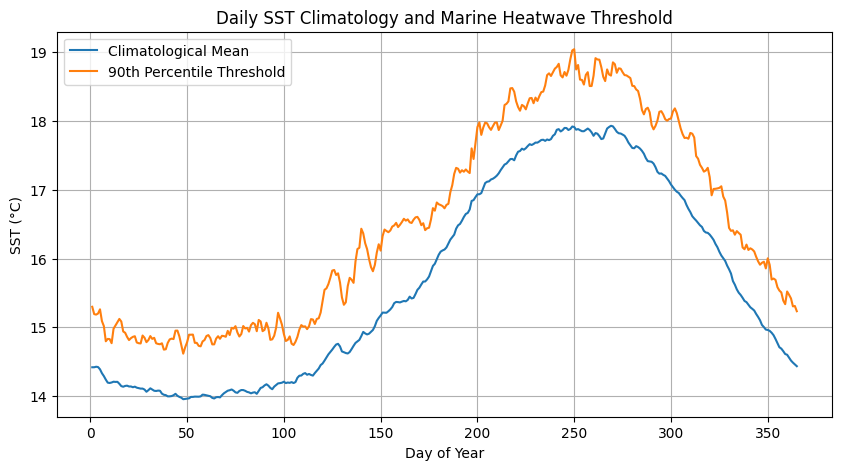

In [5]:
# 检查 climatology
print("Climatology shape:", climatology.shape)
print(climatology.describe())

plt.figure(figsize=(10, 5))
plt.plot(
    climatology["day_of_year"],
    climatology["climatological_mean"],
    label="Climatological Mean",
)
plt.plot(
    climatology["day_of_year"],
    climatology["threshold"],
    label="90th Percentile Threshold",
)
plt.title("Daily SST Climatology and Marine Heatwave Threshold")
plt.xlabel("Day of Year")
plt.ylabel("SST (°C)")
plt.legend()
plt.grid(True)
plt.show()


In [6]:
# 添加 anomaly 和 threshold
mhw_data = add_anomalies_and_thresholds(sst, climatology)

mhw_data.head()


,date,year,sst,day_of_year,climatological_mean,threshold,sst_anomaly,threshold_anomaly,above_threshold
0,1982-01-01,1982,14.619334,1,14.419488,15.299240,0.199846,0.879752,False
1,1982-01-02,1982,14.521364,2,14.419681,15.192833,0.101683,0.773153,False
2,1982-01-03,1982,14.399932,3,14.427253,15.185508,-0.027321,0.758255,False
3,1982-01-04,1982,14.327671,4,14.422400,15.201450,-0.094729,0.779050,False
4,1982-01-05,1982,14.418211,5,14.389955,15.262431,0.028256,0.872476,False


In [7]:
# 检查 anomaly
mhw_data[
    [
        "date",
        "year",
        "sst",
        "climatological_mean",
        "threshold",
        "sst_anomaly",
        "above_threshold",
    ]
].head(10)


,date,year,sst,climatological_mean,threshold,sst_anomaly,above_threshold
0,1982-01-01,1982,14.619334,14.419488,15.299240,0.199846,False
1,1982-01-02,1982,14.521364,14.419681,15.192833,0.101683,False
2,1982-01-03,1982,14.399932,14.427253,15.185508,-0.027321,False
3,1982-01-04,1982,14.327671,14.422400,15.201450,-0.094729,False
4,1982-01-05,1982,14.418211,14.389955,15.262431,0.028256,False
5,1982-01-06,1982,14.400666,14.332981,15.090826,0.067685,False
6,1982-01-07,1982,14.317087,14.290944,15.017831,0.026143,False
7,1982-01-08,1982,14.012581,14.239797,14.797627,-0.227216,False
8,1982-01-09,1982,13.842478,14.195593,14.831939,-0.353115,False
9,1982-01-10,1982,13.932867,14.190982,14.829231,-0.258115,False


In [8]:
# 检测 Marine Heatwave
mhw_labeled, mhw_events = detect_marine_heatwaves(
    mhw_data,
    min_duration=5,
)

print("Number of detected events:", len(mhw_events))
print("Total MHW days:", mhw_labeled["mhw_event_id"].notna().sum())

mhw_events.head()

Number of detected events: 101
Total MHW days: 2222


,event_id,start_date,end_date,duration_days,max_intensity,mean_intensity,cumulative_intensity,year
0,1,1982-12-22,1982-12-26,5,1.204462,1.080053,5.400263,1982
1,2,1983-01-12,1983-02-02,22,1.490115,1.098793,24.173445,1983
2,3,1983-02-06,1983-03-19,42,1.428559,1.124744,47.239255,1983
3,4,1983-08-12,1983-08-16,5,0.915038,0.795087,3.975437,1983
4,5,1983-08-18,1983-09-07,21,1.872206,1.267379,26.614949,1983


In [9]:
mhw_events.sort_values("duration_days", ascending=False).head(10)

,event_id,start_date,end_date,duration_days,max_intensity,mean_intensity,cumulative_intensity,year
57,58,2014-09-10,2015-04-29,232,2.862072,1.994270,462.670740,2015
59,60,2015-06-20,2015-11-19,153,3.227449,2.221690,339.918546,2015
43,44,1997-10-30,1998-02-27,121,1.950729,1.469287,177.783745,1997
41,42,1997-08-08,1997-10-20,74,2.176241,1.552228,114.864882,1997
97,98,2024-01-17,2024-03-24,67,1.635111,1.136792,76.165092,2024
96,97,2023-11-09,2024-01-12,65,1.577937,1.272469,82.710509,2023
87,88,2020-08-31,2020-10-28,59,2.062172,1.551887,91.561360,2020
91,92,2022-08-31,2022-10-25,56,2.020065,1.446993,81.031613,2022
62,63,2016-02-06,2016-03-27,50,1.681617,1.325730,66.286522,2016
74,75,2017-12-29,2018-02-12,46,1.541881,1.187723,54.635266,2018


In [ ]:
# 年度汇总
annual_mhw_summary = summarize_events_by_year(mhw_events)

annual_mhw_summary.head()


,year,event_count,total_mhw_days,max_duration,max_intensity,cumulative_intensity
0,1982,1,5,5,1.204462,5.400263
1,1983,7,169,42,2.168267,226.366178
2,1984,4,24,7,1.544703,28.354454
3,1986,1,5,5,1.152309,5.346383
4,1989,3,31,15,1.343403,32.044601


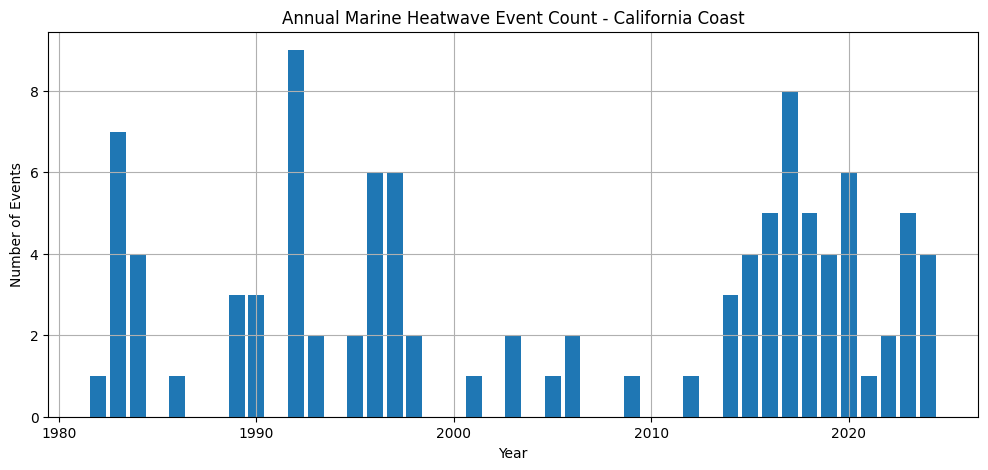

In [11]:
# 年度 Marine Heatwave 次数
plt.figure(figsize=(12, 5))
plt.bar(annual_mhw_summary["year"], annual_mhw_summary["event_count"])
plt.title("Annual Marine Heatwave Event Count - California Coast")
plt.xlabel("Year")
plt.ylabel("Number of Events")
plt.grid(True)
plt.show()


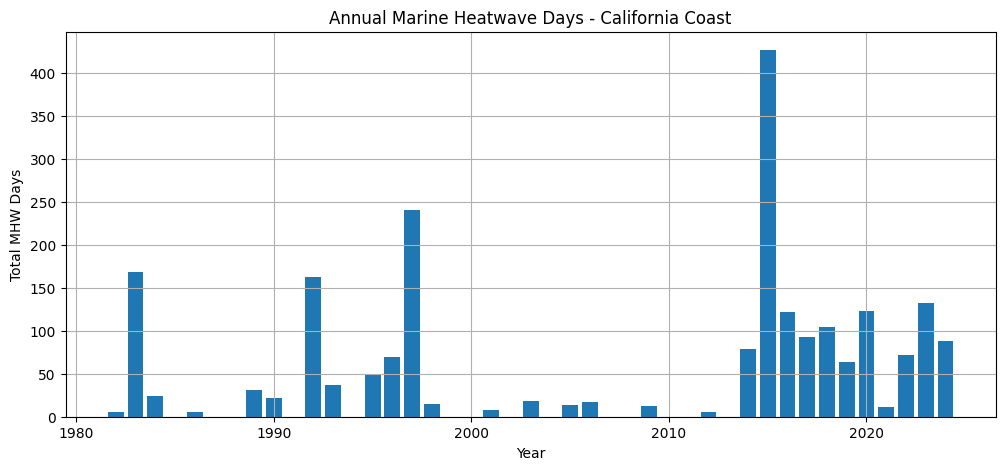

In [12]:
# 年度 MHW 天数
plt.figure(figsize=(12, 5))
plt.bar(annual_mhw_summary["year"], annual_mhw_summary["total_mhw_days"])
plt.title("Annual Marine Heatwave Days - California Coast")
plt.xlabel("Year")
plt.ylabel("Total MHW Days")
plt.grid(True)
plt.show()

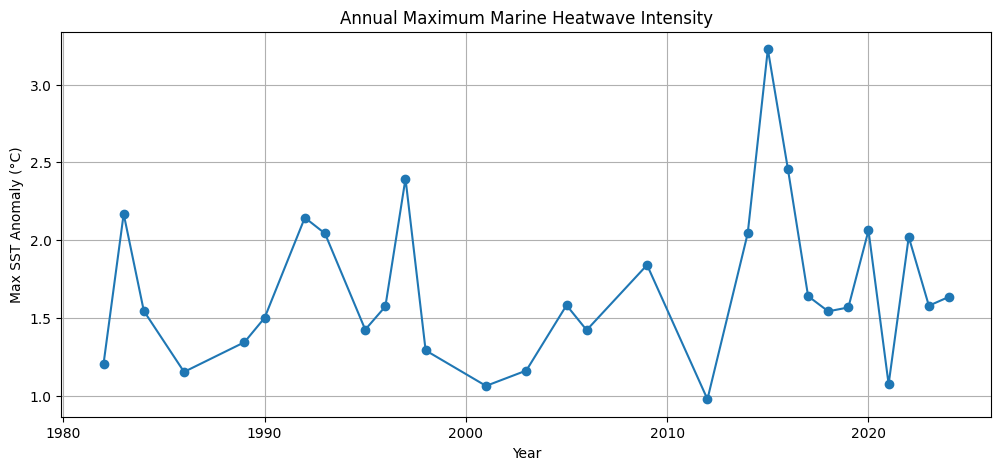

In [13]:
# 绘制最大强度
plt.figure(figsize=(12, 5))
plt.plot(
    annual_mhw_summary["year"],
    annual_mhw_summary["max_intensity"],
    marker="o",
)
plt.title("Annual Maximum Marine Heatwave Intensity")
plt.xlabel("Year")
plt.ylabel("Max SST Anomaly (°C)")
plt.grid(True)
plt.show()

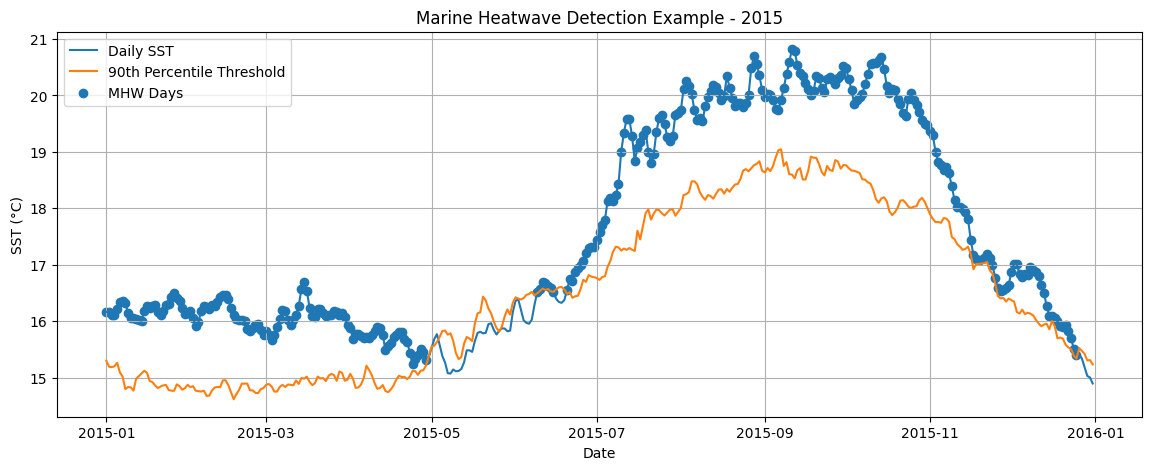

In [14]:
# 选择一个年份可视化
selected_year = 2015

plot_data = mhw_labeled[mhw_labeled["year"] == selected_year].copy()
mhw_days = plot_data[plot_data["mhw_event_id"].notna()]

plt.figure(figsize=(14, 5))

plt.plot(plot_data["date"], plot_data["sst"], label="Daily SST")
plt.plot(plot_data["date"], plot_data["threshold"], label="90th Percentile Threshold")

plt.scatter(
    mhw_days["date"],
    mhw_days["sst"],
    label="MHW Days",
)

plt.title(f"Marine Heatwave Detection Example - {selected_year}")
plt.xlabel("Date")
plt.ylabel("SST (°C)")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
# 查看2015年事件
mhw_events[mhw_events["year"] == selected_year]


,event_id,start_date,end_date,duration_days,max_intensity,mean_intensity,cumulative_intensity,year
57,58,2014-09-10,2015-04-29,232,2.862072,1.994270,462.670740,2015
58,59,2015-06-09,2015-06-15,7,1.314874,1.205266,8.436860,2015
59,60,2015-06-20,2015-11-19,153,3.227449,2.221690,339.918546,2015
60,61,2015-11-21,2015-12-25,35,1.694701,1.213239,42.463360,2015


In [16]:
mhw_labeled_path = PROCESSED_DIR / "mhw_daily_labeled_1982_2024.csv"
mhw_events_path = PROCESSED_DIR / "mhw_events_1982_2024.csv"
annual_summary_path = PROCESSED_DIR / "mhw_annual_summary_1982_2024.csv"
climatology_path = PROCESSED_DIR / "mhw_climatology_1982_2011.csv"

mhw_labeled.to_csv(mhw_labeled_path, index=False)
mhw_events.to_csv(mhw_events_path, index=False)
annual_mhw_summary.to_csv(annual_summary_path, index=False)
climatology.to_csv(climatology_path, index=False)

print("Saved:", mhw_labeled_path)
print("Saved:", mhw_events_path)
print("Saved:", annual_summary_path)
print("Saved:", climatology_path)


Saved: /Users/sumi/Desktop/project/data/processed/mhw_daily_labeled_1982_2024.csv
Saved: /Users/sumi/Desktop/project/data/processed/mhw_events_1982_2024.csv
Saved: /Users/sumi/Desktop/project/data/processed/mhw_annual_summary_1982_2024.csv
Saved: /Users/sumi/Desktop/project/data/processed/mhw_climatology_1982_2011.csv
